# 09 · Forest masks from HV backscatter

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bullocke/nice-sar/blob/main/notebooks/09_forest_masks.ipynb)

Many forest analyses start with one question: which pixels are forest? L-band HV backscatter answers it well, because it comes mostly from volume scattering in the canopy's branches (trunks contribute mainly to HH, through double bounce with the ground). This notebook builds forest masks from NISAR HV over Caquetá, Colombia, and checks them against an independent map.

**What you will learn**

- List the forest-mask methods in nice-sar with `list_forest_mask_methods`.
- Make an HV threshold mask with `generate_forest_mask`, and why literature thresholds need local tuning.
- Measure agreement with a reference map (RADD's primary forest baseline).
- Load and align an external forest mask with `load_external_forest_mask`.

> **Provisional data.** NISAR products used here are PROVISIONAL: calibrated but only partly validated. Numbers may shift once validated products are released.

**Runtime:** under 1 minute with the demo bundle (no login needed).

In [1]:
# Colab only: install nice-sar (about 1 minute)
import sys

if "google.colab" in sys.modules:
    %pip install -q "fsspec<=2025.3.0" "s3fs<=2025.3.0" "nice-sar @ git+https://github.com/bullocke/nice-sar.git@main"

In [2]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.crs import CRS

from nice_sar.analysis.disturbance import boxcar_db
from nice_sar.datasets import load_caqueta_demo
from nice_sar.forests import generate_forest_mask, list_forest_mask_methods, load_external_forest_mask
from nice_sar.io.geotiff import write_geotiff
from nice_sar.viz.style import CMAPS, COLORS, add_colorbar, add_scalebar, image_axes, use_nice_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s", force=True)
logging.getLogger("PIL").setLevel(logging.WARNING)
log = logging.getLogger("nb09")
warnings.filterwarnings("ignore", message="(All-NaN slice|Mean of empty slice)")
use_nice_style()
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 90}}

OUT = Path("outputs") / "09"
OUT.mkdir(parents=True, exist_ok=True)

## 1. Methods available

nice-sar keeps a registry of forest-mask methods. Three HV threshold methods and an external-raster loader are implemented; the others are placeholders for methods planned from the literature.

In [3]:
methods = pd.DataFrame(list_forest_mask_methods())[["name", "implemented", "default_threshold_db", "description"]]
methods.sort_values("implemented", ascending=False).reset_index(drop=True)

,name,implemented,default_threshold_db,description
0,external_raster,True,NaN,Load an external raster or COG and interpret i...
1,gcov_hv_threshold,True,-20.0,GCOV HV backscatter thresholding with configur...
2,gcov_hv_threshold_jaxa_biomass,True,-13.0,GCOV HV threshold preset using -13 dB.
3,gcov_hv_threshold_ramachandran,True,-20.0,GCOV HV threshold preset using -20 dB.
4,gcov_dprvi_glcm_texture,False,NaN,GCOV DpRVI and GLCM texture-based forest discr...
5,gslc_coherence_assisted,False,NaN,GSLC or GUNW coherence-assisted forest masking.
6,hv_timeseries_disturbance,False,NaN,Multitemporal HV disturbance-based forest mask...
7,nisar_official_mask,False,NaN,Official NISAR forest-related mask ingestion.
8,rfdi_multisensor,False,NaN,RFDI plus external optical or ancillary products.


## 2. An HV image with little speckle

The demo bundle holds 11 HV images of the study area from December 2025 to August 2026, cut from full NISAR GCOV frames. Averaging the first two dates (9 December 2025 and 2 January 2026) in linear power, then a 5 × 5 boxcar (`boxcar_db`), gives a clean picture of the forest at the start of the season. We wrap it as an `xarray.DataArray` with its grid in the attributes, which is what `generate_forest_mask` expects for in-memory data.

INFO: Caquetá demo: 11 HV dates, 21 coherence pairs, 40 cases


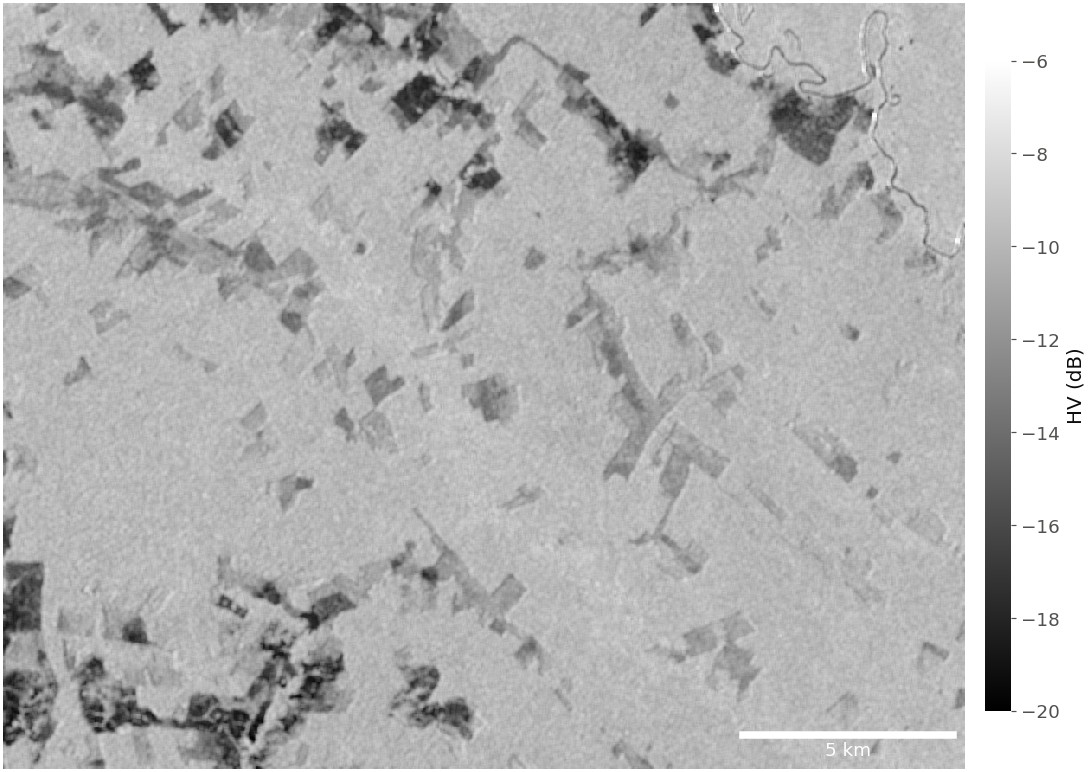

In [4]:
demo = load_caqueta_demo()
PX = demo.pixel_m
early = 10 * np.log10(np.nanmean(10 ** (demo.hv[:2] / 10), 0))
hv_db = boxcar_db(early[None], 5)[0]
hv = xr.DataArray(hv_db, dims=["y", "x"], attrs={"crs": demo.crs, "transform": tuple(demo.transform)[:6], "units": "db"})

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(hv_db, **CMAPS["hv"])
image_axes(ax)
add_scalebar(ax, PX)
add_colorbar(im, ax, "HV (dB)")
plt.show()

## 3. Reference forest and the HV histogram

As a reference we use the primary humid forest baseline distributed with the [RADD](https://www.wur.nl/en/research-results/chair-groups/environmental-sciences/laboratory-of-geo-information-science-and-remote-sensing/research/sensing-measuring/radd-forest-disturbance-alert.htm) alerts, minus land RADD flagged as cleared before February 2026. RADD alerts lag clearing by several weeks, so this also removes most forest felled in December, which our HV image already sees as open. It is an independent product built from optical and C-band radar data.

The histograms show the HV of reference forest and non-forest. The two published presets sit far from the gap between them: −20 dB (`gcov_hv_threshold_ramachandran`) marks almost everything as forest here, and −13 dB (`gcov_hv_threshold_jaxa_biomass`) still maps about two thirds of the non-forest as forest. Presets are tuned to other sensors, resolutions and landscapes, so we also pick the threshold that best separates the classes in this scene.

INFO: Threshold with the best balanced accuracy: -10.5 dB


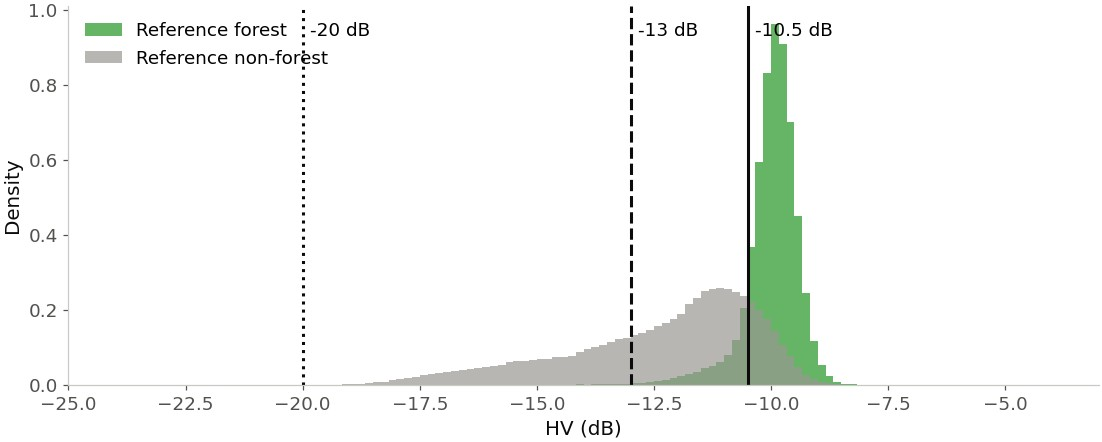

In [5]:
ref_forest = demo.radd_forest & ~(demo.radd_alert < np.datetime64("2026-02-01"))
valid = np.isfinite(hv_db)
candidates = np.arange(-16.0, -8.0, 0.1)
balanced = [0.5 * ((hv_db[ref_forest & valid] >= t).mean() + (hv_db[~ref_forest & valid] < t).mean()) for t in candidates]
tuned = float(np.round(candidates[int(np.argmax(balanced))], 1))
log.info("Threshold with the best balanced accuracy: %.1f dB", tuned)

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(-24, -4, 121)
ax.hist(hv_db[ref_forest & valid], bins=bins, density=True, color=COLORS["coh80"], alpha=0.6, label="Reference forest")
ax.hist(hv_db[~ref_forest & valid], bins=bins, density=True, color=COLORS["pasture"], alpha=0.7, label="Reference non-forest")
for t, ls in [(-20, ":"), (-13, "--"), (tuned, "-")]:
    ax.axvline(t, color=COLORS["ink"], ls=ls, lw=2)
    ax.text(t + 0.15, ax.get_ylim()[1] * 0.92, f"{t:g} dB", fontsize=12)
ax.set_xlabel("HV (dB)")
ax.set_ylabel("Density")
ax.legend(loc="upper left")
ax.grid(False)
plt.show()

## 4. Generate masks and score them

`generate_forest_mask` returns a `ForestMaskResult` with the mask, the threshold and a confidence layer (the dB margin above or below the threshold). We score each mask against the reference. Overall accuracy flatters a mask that calls nearly everything forest, because forest covers about 80% of the scene, so we also report balanced accuracy (the mean of the forest and non-forest hit rates) and, for the forest class, user's accuracy (how often a pixel mapped as forest is forest) and producer's accuracy (how much reference forest the mask finds). The tuned threshold trades a little forest recall for far fewer false forest pixels.

In [6]:
results = {
    "−20 dB preset": generate_forest_mask(hv, method="gcov_hv_threshold_ramachandran", units="db"),
    "−13 dB preset": generate_forest_mask(hv, method="gcov_hv_threshold_jaxa_biomass", units="db"),
    f"Tuned {tuned:g} dB": generate_forest_mask(hv, method="gcov_hv_threshold", threshold_db=tuned, units="db"),
}


def score(mask: np.ndarray) -> dict[str, float]:
    m, r = mask[valid], ref_forest[valid]
    return {
        "overall accuracy": (m == r).mean(),
        "balanced accuracy": 0.5 * ((m & r).sum() / r.sum() + (~m & ~r).sum() / (~r).sum()),
        "forest user's accuracy": (m & r).sum() / m.sum(),
        "forest producer's accuracy": (m & r).sum() / r.sum(),
        "non-forest mapped as forest": (m & ~r).sum() / (~r).sum(),
        "forest share": m.mean(),
    }


table = pd.DataFrame({name: score(np.asarray(res.mask)) for name, res in results.items()}).T
log.info("\n%s", table.round(3).to_string())
table.style.format("{:.1%}")

INFO: 
                overall accuracy  balanced accuracy  forest user's accuracy  forest producer's accuracy  non-forest mapped as forest  forest share
−20 dB preset              0.790              0.500                   0.790                       1.000                        1.000         1.000
−13 dB preset              0.854              0.657                   0.846                       0.997                        0.682         0.931
Tuned -10.5 dB             0.868              0.853                   0.950                       0.879                        0.173         0.730


,overall accuracy,balanced accuracy,forest user's accuracy,forest producer's accuracy,non-forest mapped as forest,forest share
−20 dB preset,79.0%,50.0%,79.0%,100.0%,100.0%,100.0%
−13 dB preset,85.4%,65.7%,84.6%,99.7%,68.2%,93.1%
Tuned -10.5 dB,86.8%,85.3%,95.0%,87.9%,17.3%,73.0%


## 5. Where the tuned mask and the reference disagree

The map colours each pixel by agreement. Most of the scene agrees. NISAR-only forest (light green) may include secondary regrowth and tall fallow on old clearings, which can scatter like forest at L-band but is not in a primary forest baseline. Reference-only forest (orange) sits along clearing edges, where the 5 × 5 filter blurs the boundary, and on land that was open in HV but not yet in the reference, such as clearings RADD missed or dated later.

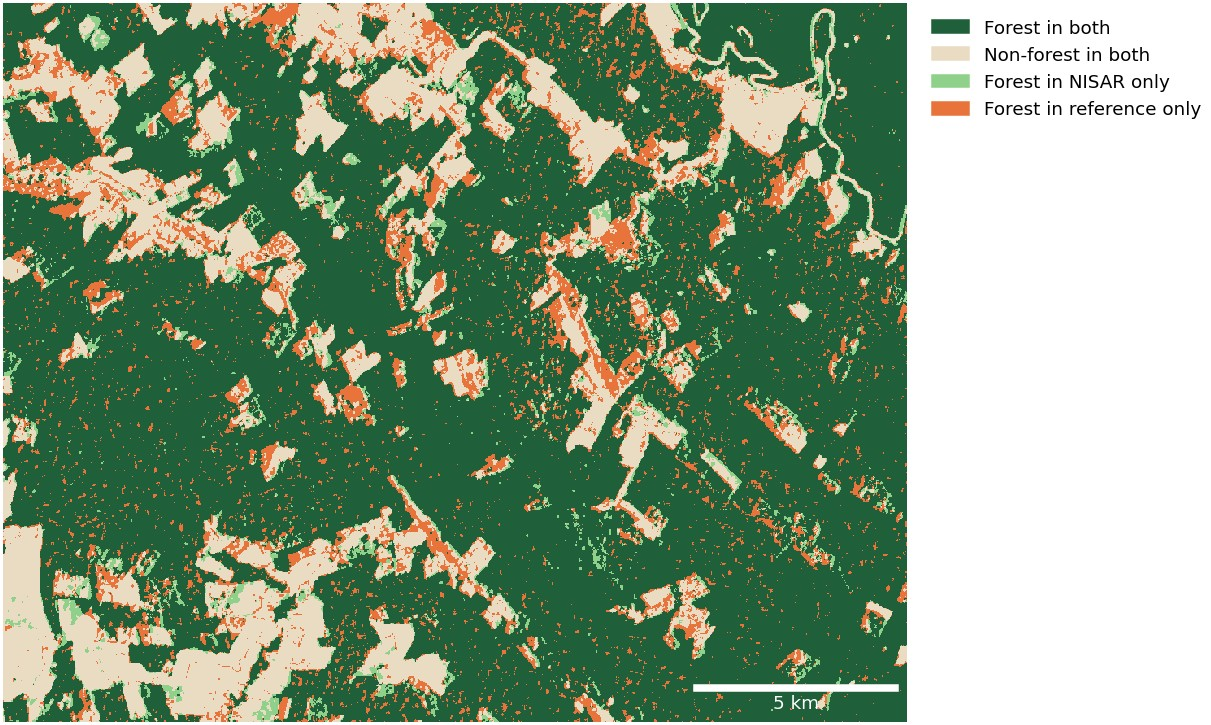

INFO: Agreement: 86.8% of pixels


In [7]:
mask = np.asarray(results[f"Tuned {tuned:g} dB"].mask)
classes = np.full(demo.shape, np.nan)
classes[mask & ref_forest] = 0
classes[~mask & ~ref_forest] = 1
classes[mask & ~ref_forest] = 2
classes[~mask & ref_forest] = 3
colors = ["#1f5f3a", "#e9dcc3", "#8fd18a", "#e8743b"]
labels = ["Forest in both", "Non-forest in both", "Forest in NISAR only", "Forest in reference only"]

fig, ax = plt.subplots(figsize=(11, 7.6))
ax.imshow(classes, cmap=ListedColormap(colors), vmin=-0.5, vmax=3.5)
image_axes(ax)
add_scalebar(ax, PX, color="white")
ax.legend(handles=[Patch(color=c, label=l) for c, l in zip(colors, labels)], loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.show()
log.info("Agreement: %.1f%% of pixels", 100 * np.isin(classes, [0, 1]).mean())

The confidence layer shows how far each pixel sits from the threshold. Pixels within about 1 dB of it (pale) are the uncertain ones: forest edges, regrowth and wet pasture.

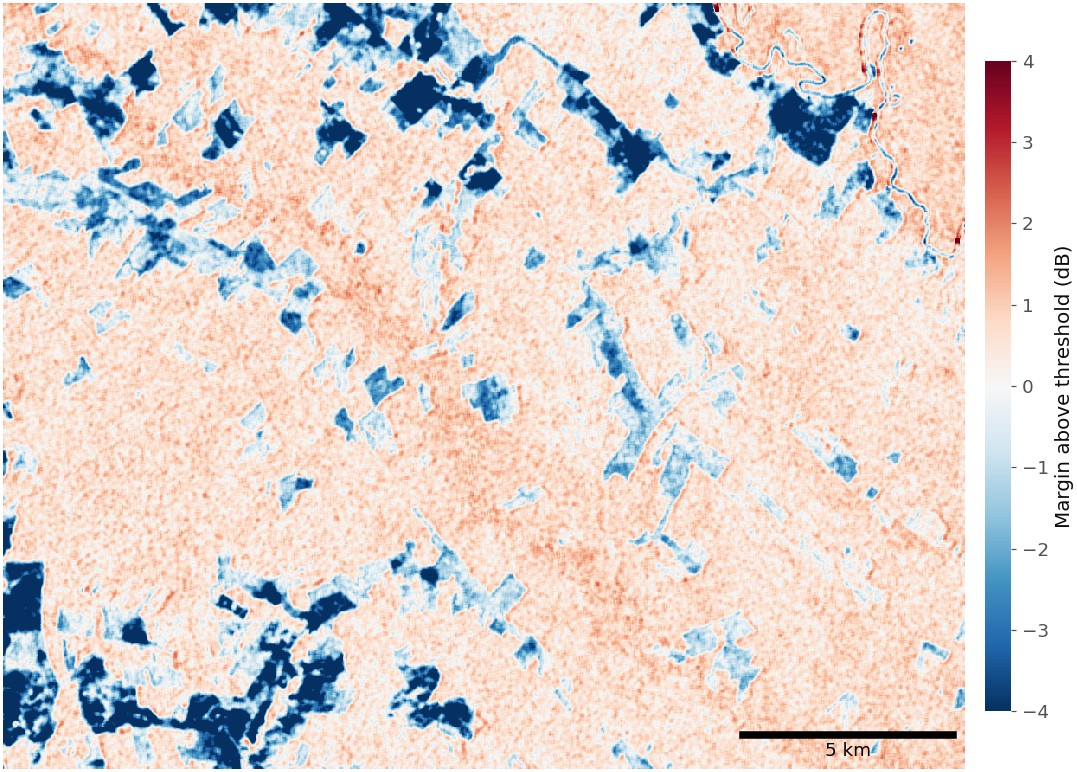

In [8]:
margin = np.asarray(results[f"Tuned {tuned:g} dB"].confidence)
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(margin, cmap=CMAPS["difference"]["cmap"], vmin=-4, vmax=4)
image_axes(ax)
add_scalebar(ax, PX, color="black")
add_colorbar(im, ax, "Margin above threshold (dB)")
plt.show()

## 6. Load and align an external mask

External forest maps rarely share the NISAR grid. `load_external_forest_mask` reads any GeoTIFF or cloud-optimized GeoTIFF (local, HTTPS or S3), reprojects it onto a target grid, and converts it to a boolean mask from a threshold or a list of class values. Here we write the RADD baseline to a GeoTIFF and load it back onto the HV grid; with a real product you would pass its path or URL.

In [9]:
radd_path = OUT / "radd_forest_baseline.tif"
write_geotiff(radd_path, demo.radd_forest.astype("float32"), transform=demo.transform, crs=CRS.from_string(demo.crs))

external = load_external_forest_mask(radd_path, target=hv, mask_values=(1,))
ext_mask = np.asarray(external.mask)
log.info("External mask %s on the HV grid: %.1f%% forest; identical to the baseline: %s", ext_mask.shape, 100 * ext_mask.mean(), bool((ext_mask == demo.radd_forest).all()))

INFO: Exported: radd_forest_baseline.tif


INFO: External mask (885, 1112) on the HV grid: 95.5% forest; identical to the baseline: True


## Summary

- `generate_forest_mask` makes HV threshold masks from NISAR GCOV, arrays or GeoTIFFs, with a confidence margin.
- Published thresholds do not transfer between regions and sensors; tuning on a reference map raised balanced accuracy from 0.66 to 0.85 and cut the share of non-forest mapped as forest from 68% to 17% (about three quarters fewer) compared with the −13 dB preset.
- Disagreements with a primary-forest reference sit mainly along clearing edges and on old clearings that may hold regrowth.
- `load_external_forest_mask` aligns any external map to the NISAR grid.

Previous tutorial: [08 · Subset download](08_subset_download.ipynb). Next: [10 · Texture](10_texture_comparison.ipynb).

In [10]:
import nice_sar

log.info("nice-sar %s, run on %s", nice_sar.__version__, np.datetime64("today"))

INFO: nice-sar 0.2.0, run on 2026-09-25
